"""РК1_ИУ5-61Б_Шибанова_Варвара.ipynb
"""

# Задача №3
- Для заданного набора данных произведите масштабирование данных (для одного признака) и преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака.

     + Для студентов групп ИУ5-61Б, ИУ5Ц-81Б - для пары произвольных колонок данных построить график "Диаграмма рассеяния".



## Описание колонок датасета Boston Housing

| № | Колонка | Название | Описание | Тип данных | Диапазон значений |
|---|---------|----------|----------|------------|------------------|
| 1 | **CRIM** | Per capita crime rate by town | Уровень преступности на душу населения по городу | Числовой (float) | 0.00632 - 88.9762 |
| 2 | **ZN** | Proportion of residential land zoned for lots over 25,000 sq.ft. | Доля земли, отведенной под жилые участки площадью более 25,000 кв. футов | Числовой (float) | 0 - 100 |
| 3 | **INDUS** | Proportion of non-retail business acres per town | Доля не розничных коммерческих площадей на город | Числовой (float) | 0.46 - 27.74 |
| 4 | **CHAS** | Charles River dummy variable | Фиктивная переменная: 1 - если участок граничит с рекой Чарльз, 0 - иначе | Бинарный (int) | 0 или 1 |
| 5 | **NOX** | Nitric oxides concentration | Концентрация оксидов азота (в частях на 10 миллионов) | Числовой (float) | 0.385 - 0.871 |
| 6 | **RM** | Average number of rooms per dwelling | Среднее количество комнат на одно жилье | Числовой (float) | 3.561 - 8.78 |
| 7 | **AGE** | Proportion of owner-occupied units built prior to 1940 | Доля домов, построенных до 1940 года, находящихся в собственности владельцев | Числовой (float) | 2.9 - 100 |
| 8 | **DIS** | Weighted distances to five Boston employment centres | Взвешенные расстояния до пяти центров занятости в Бостоне | Числовой (float) | 1.1296 - 12.1265 |
| 9 | **RAD** | Index of accessibility to radial highways | Индекс доступности к радиальным магистралям | Числовой (int) | 1 - 24 |
| 10 | **TAX** | Property-tax rate per $10,000 | Ставка налога на имущество за $10,000 | Числовой (int) | 187 - 711 |
| 11 | **PTRATIO** | Pupil-teacher ratio by town | Соотношение учеников к учителям по городу | Числовой (float) | 12.6 - 22.0 |
| 12 | **B** | 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town | Параметр, характеризующий долю афроамериканцев в городе | Числовой (float) | 0.32 - 396.9 |
| 13 | **LSTAT** | Percentage of lower status of the population | Процент населения с низким социально-экономическим статусом | Числовой (float) | 1.73 - 37.97 |
| 14 | **MEDV** | Median value of owner-occupied homes in $1000's | Медианная стоимость домов в тысячах долларов (целевая переменная) | Числовой (float) | 5.0 - 50.0 |

---

### Дополнительная информация

#### Источник данных
Датасет Boston Housing взят из UCI Machine Learning Repository и содержит информацию о жилье в пригородах Бостона.

#### Количество наблюдений
- Всего записей: **506**
- В исходных данных есть пропуски (в файле HousingData.csv), которые были обработаны в ходе работы

#### Типы признаков

| Категория | Признаки |
|-----------|----------|
| **Социально-экономические** | CRIM, ZN, INDUS, CHAS, B, LSTAT |
| **Экологические** | NOX, AGE, DIS |
| **Архитектурные** | RM, AGE |
| **Инфраструктурные** | RAD, TAX, PTRATIO, DIS |
| **Целевая переменная** | MEDV |

#### Особенности датасета
- **CHAS** - единственный бинарный признак (у реки/не у реки)
- **MEDV** - целевая переменная, которую обычно предсказывают
- Данные имеют различные масштабы (от единиц до сотен), что требует нормализации/масштабирования

#### Статистика по колонкам после обработки пропусков

In [30]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков (используем доступные стили)
# Проверим доступные стили
print("Доступные стили matplotlib:", plt.style.available[:5])
print()

# Используем стиль 'seaborn-v0_8' если доступен, иначе 'default'
try:
    plt.style.use('seaborn-v0_8')
    print("Используется стиль: seaborn-v0_8")
except:
    try:
        plt.style.use('seaborn')
        print("Используется стиль: seaborn")
    except:
        plt.style.use('default')
        print("Используется стиль: default")

# Настройка параметров графиков
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


Доступные стили matplotlib: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh']

Используется стиль: seaborn-v0_8


# ШАГ 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

In [31]:
print("\n" + "=" * 80)
print("АНАЛИЗ ДАТАСЕТА BOSTON HOUSING")
print("=" * 80)
print()

print("ШАГ 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("-" * 50)

# Загрузка данных
df = pd.read_csv('HousingData.csv')

print(f"Размер датасета: {df.shape}")
print(f"\nКоличество пропусков по колонкам:")
print(df.isnull().sum())
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПервые 5 строк:\n{df.head()}")



АНАЛИЗ ДАТАСЕТА BOSTON HOUSING

ШАГ 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
--------------------------------------------------
Размер датасета: (506, 14)

Количество пропусков по колонкам:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Типы данных:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Первые 5 строк:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4

# ШАГ 2: ОБРАБОТКА ПРОПУСКОВ

In [32]:
print("\n" + "=" * 80)
print("ШАГ 2: ОБРАБОТКА ПРОПУСКОВ")
print("=" * 80)

# Выводим информацию о пропусках до обработки
print("Пропуски до обработки:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Заполняем пропуски медианными значениями для числовых колонок
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Колонка '{col}': заполнено {df[col].isnull().sum()} пропусков медианой = {median_val:.4f}")

# Проверяем, что пропусков больше нет
print(f"\nПропуски после обработки: {df.isnull().sum().sum()}")

print("\nПервые 5 строк после заполнения пропусков:")
print(df.head())


ШАГ 2: ОБРАБОТКА ПРОПУСКОВ
Пропуски до обработки:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64
Колонка 'CRIM': заполнено 0 пропусков медианой = 0.2537
Колонка 'ZN': заполнено 0 пропусков медианой = 0.0000
Колонка 'INDUS': заполнено 0 пропусков медианой = 9.6900
Колонка 'CHAS': заполнено 0 пропусков медианой = 0.0000
Колонка 'AGE': заполнено 0 пропусков медианой = 76.8000
Колонка 'LSTAT': заполнено 0 пропусков медианой = 11.4300

Пропуски после обработки: 0

Первые 5 строк после заполнения пропусков:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0

# ШАГ 3: СОЗДАНИЕ КАТЕГОРИАЛЬНОГО ПРИЗНАКА

In [33]:
print("\n" + "=" * 80)
print("ШАГ 3: СОЗДАНИЕ КАТЕГОРИАЛЬНОГО ПРИЗНАКА")
print("=" * 80)

# Создаем категориальный признак на основе CHAS (Charles River)
# CHAS - бинарный признак (0 или 1), преобразуем его в категориальный с названиями
df['CHAS_cat'] = df['CHAS'].map({0: 'not_bound', 1: 'bound_river'})
print("Создан категориальный признак 'CHAS_cat' на основе колонки 'CHAS'")
print(f"\nРаспределение категорий:\n{df['CHAS_cat'].value_counts()}")


ШАГ 3: СОЗДАНИЕ КАТЕГОРИАЛЬНОГО ПРИЗНАКА
Создан категориальный признак 'CHAS_cat' на основе колонки 'CHAS'

Распределение категорий:
CHAS_cat
not_bound      472
bound_river     34
Name: count, dtype: int64


# ШАГ 4: МАСШТАБИРОВАНИЕ ДАННЫХ

In [34]:
print("\n" + "=" * 80)
print("ШАГ 4: МАСШТАБИРОВАНИЕ ДАННЫХ")
print("=" * 80)

# Выбираем признак для масштабирования
feature_to_scale = 'RM'
print(f"Выбран признак: {feature_to_scale} - 'среднее количество комнат'")
print(f"Статистика до масштабирования:")
print(f"  Среднее: {df[feature_to_scale].mean():.4f}")
print(f"  Стандартное отклонение: {df[feature_to_scale].std():.4f}")
print(f"  Мин: {df[feature_to_scale].min():.4f}")
print(f"  Макс: {df[feature_to_scale].max():.4f}")

# Стандартизация (StandardScaler) - приводит к среднему 0 и стандартному отклонению 1
scaler = StandardScaler()
df['RM_scaled'] = scaler.fit_transform(df[[feature_to_scale]])

print(f"\nСтатистика после масштабирования (StandardScaler):")
print(f"  Среднее: {df['RM_scaled'].mean():.6f}")
print(f"  Стандартное отклонение: {df['RM_scaled'].std():.6f}")
print(f"  Мин: {df['RM_scaled'].min():.4f}")
print(f"  Макс: {df['RM_scaled'].max():.4f}")


ШАГ 4: МАСШТАБИРОВАНИЕ ДАННЫХ
Выбран признак: RM - 'среднее количество комнат'
Статистика до масштабирования:
  Среднее: 6.2846
  Стандартное отклонение: 0.7026
  Мин: 3.5610
  Макс: 8.7800

Статистика после масштабирования (StandardScaler):
  Среднее: -0.000000
  Стандартное отклонение: 1.000990
  Мин: -3.8802
  Макс: 3.5550


# ШАГ 5: ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

In [35]:
print("\n" + "=" * 80)
print("ШАГ 5: ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 80)

# Способ 1: Label Encoding
print("\n" + "=" * 40)
print("Способ 1: LABEL ENCODING")
print("=" * 40)

label_encoder = LabelEncoder()
df['CHAS_label'] = label_encoder.fit_transform(df['CHAS_cat'])

print(f"  Соответствие категорий:")
for i, category in enumerate(label_encoder.classes_):
    print(f"    '{category}' -> {i}")

print(f"\n  Пример преобразования:")
print(df[['CHAS_cat', 'CHAS_label']].head(10))

# Способ 2: One-Hot Encoding
print("\n" + "=" * 40)
print("Способ 2: ONE-HOT ENCODING")
print("=" * 40)

one_hot_encoder = OneHotEncoder(sparse_output=False)
chass_onehot = one_hot_encoder.fit_transform(df[['CHAS_cat']])

# Создаем DataFrame с one-hot кодированием
chass_onehot_df = pd.DataFrame(
    chass_onehot,
    columns=[f'CHAS_{cat}' for cat in one_hot_encoder.categories_[0]],
    index=df.index
)

df = pd.concat([df, chass_onehot_df], axis=1)

print(f"  Создано колонок: {chass_onehot_df.shape[1]}")
print(f"  Колонки: {list(chass_onehot_df.columns)}")
print(f"\n  Пример преобразования:")
print(df[['CHAS_cat', 'CHAS_bound_river', 'CHAS_not_bound']].head(10))


ШАГ 5: ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Способ 1: LABEL ENCODING
  Соответствие категорий:
    'bound_river' -> 0
    'not_bound' -> 1

  Пример преобразования:
    CHAS_cat  CHAS_label
0  not_bound           1
1  not_bound           1
2  not_bound           1
3  not_bound           1
4  not_bound           1
5  not_bound           1
6  not_bound           1
7  not_bound           1
8  not_bound           1
9  not_bound           1

Способ 2: ONE-HOT ENCODING
  Создано колонок: 2
  Колонки: ['CHAS_bound_river', 'CHAS_not_bound']

  Пример преобразования:
    CHAS_cat  CHAS_bound_river  CHAS_not_bound
0  not_bound               0.0             1.0
1  not_bound               0.0             1.0
2  not_bound               0.0             1.0
3  not_bound               0.0             1.0
4  not_bound               0.0             1.0
5  not_bound               0.0             1.0
6  not_bound               0.0             1.0
7  not_bound               0.0             1.0
8  not_

# ШАГ 6: СРАВНЕНИЕ МЕТОДОВ КОДИРОВАНИЯ

LABEL ENCODING:
  - Преимущества:
    * Не увеличивает размерность данных
    * Простой и быстрый
    * Хорош для порядковых категорий (ordinal)
  - Недостатки:
    * Может создавать ложные порядковые отношения между категориями
    * Не подходит для номинальных категорий (nominal)
    * Может негативно влиять на модели, чувствительные к порядку

ONE-HOT ENCODING:
  - Преимущества:
    * Не создает ложных порядковых отношений
    * Подходит для любых категориальных данных
    * Хорошо работает с большинством ML моделей
  - Недостатки:
    * Увеличивает размерность данных
    * Может вызвать проблему "проклятия размерности"
    * Требует больше памяти

В данном случае признак CHAS_cat является бинарным и номинальным,
поэтому оба подхода будут работать корректно.


# ШАГ 7: ПОСТРОЕНИЕ ГРАФИКОВ (Диаграммы рассеяния для пар колонок)


ШАГ 7: ПОСТРОЕНИЕ ГРАФИКОВ - ДИАГРАММЫ РАССЕЯНИЯ


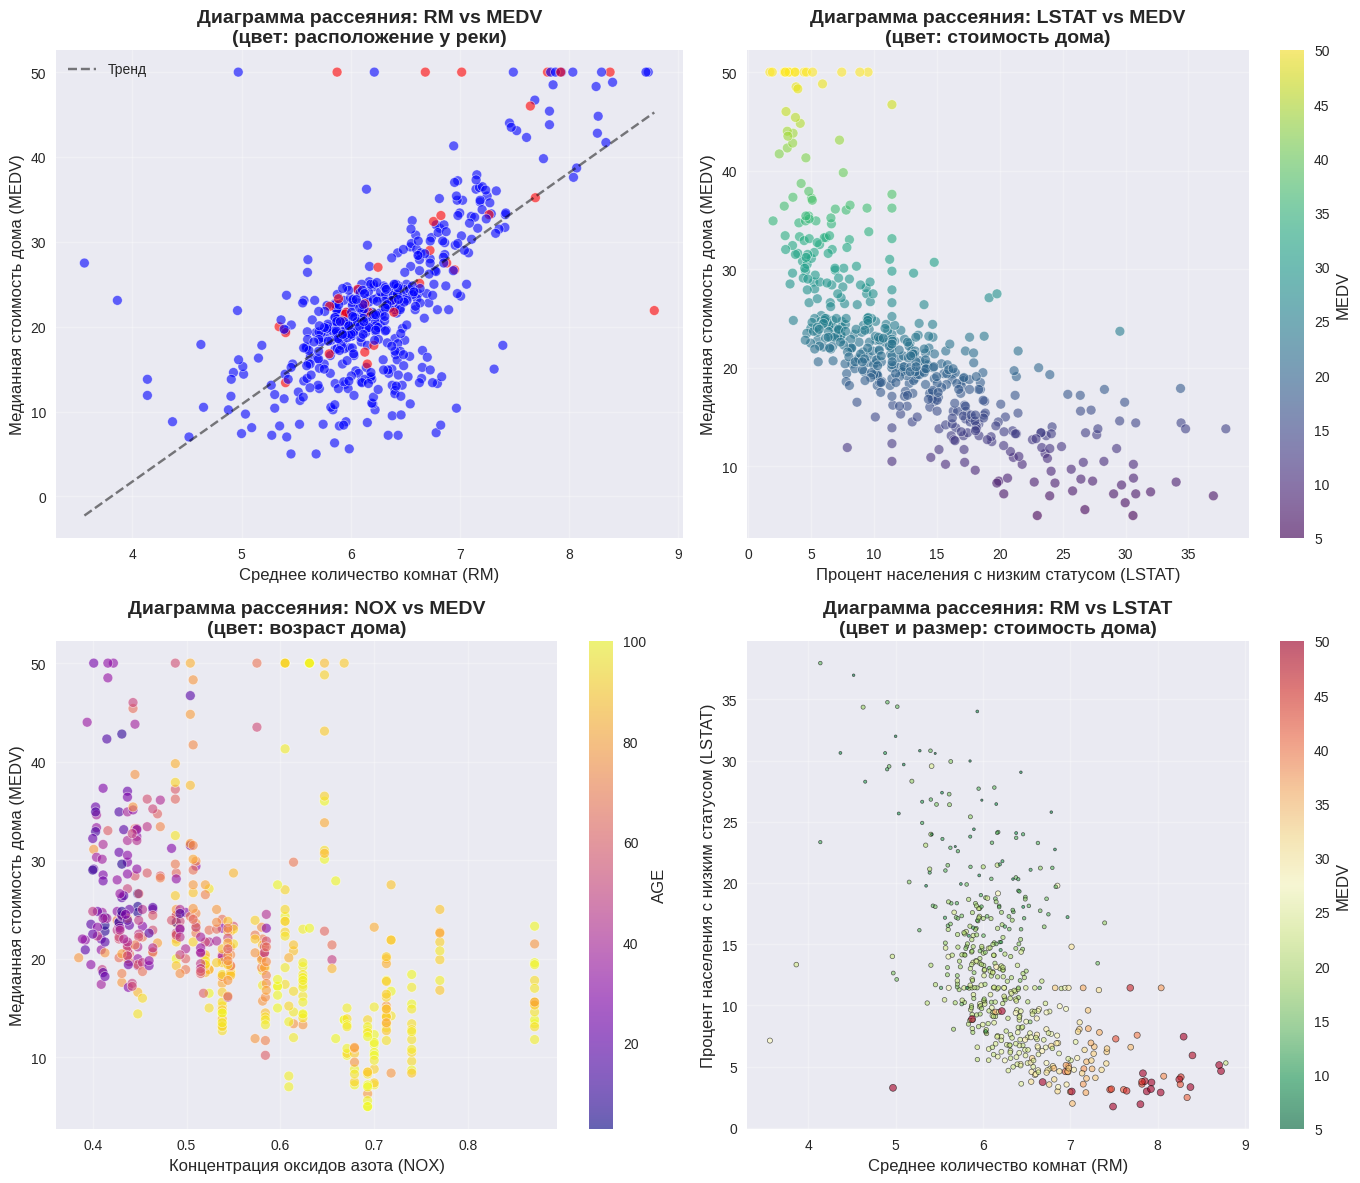

In [36]:
print("\n" + "=" * 80)
print("ШАГ 7: ПОСТРОЕНИЕ ГРАФИКОВ - ДИАГРАММЫ РАССЕЯНИЯ")
print("=" * 80)

# Создаем фигуру с несколькими графиками
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# График 1: Диаграмма рассеяния RM vs MEDV (количество комнат vs стоимость)
colors = df['CHAS_cat'].map({'not_bound': 'blue', 'bound_river': 'red'})
scatter1 = axes[0, 0].scatter(df['RM'], df['MEDV'], c=colors,
                              alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
axes[0, 0].set_xlabel('Среднее количество комнат (RM)', fontsize=12)
axes[0, 0].set_ylabel('Медианная стоимость дома (MEDV)', fontsize=12)
axes[0, 0].set_title('Диаграмма рассеяния: RM vs MEDV\n(цвет: расположение у реки)', fontsize=14, fontweight='bold')
axes[0, 0].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Не у реки'),
                           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='У реки')])
axes[0, 0].grid(True, alpha=0.3)

# Добавляем линию тренда
z = np.polyfit(df['RM'], df['MEDV'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['RM'].sort_values(), p(df['RM'].sort_values()), 'k--', alpha=0.5, label='Тренд')
axes[0, 0].legend()

# График 2: Диаграмма рассеяния LSTAT vs MEDV (процент населения с низким статусом vs стоимость)
scatter2 = axes[0, 1].scatter(df['LSTAT'], df['MEDV'], c=df['MEDV'], cmap='viridis',
                              alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
axes[0, 1].set_xlabel('Процент населения с низким статусом (LSTAT)', fontsize=12)
axes[0, 1].set_ylabel('Медианная стоимость дома (MEDV)', fontsize=12)
axes[0, 1].set_title('Диаграмма рассеяния: LSTAT vs MEDV\n(цвет: стоимость дома)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='MEDV')

# График 3: Диаграмма рассеяния NOX vs MEDV (концентрация оксидов азота vs стоимость)
scatter3 = axes[1, 0].scatter(df['NOX'], df['MEDV'], c=df['AGE'], cmap='plasma',
                              alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
axes[1, 0].set_xlabel('Концентрация оксидов азота (NOX)', fontsize=12)
axes[1, 0].set_ylabel('Медианная стоимость дома (MEDV)', fontsize=12)
axes[1, 0].set_title('Диаграмма рассеяния: NOX vs MEDV\n(цвет: возраст дома)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='AGE')

# График 4: Диаграмма рассеяния RM vs LSTAT с размером точек по MEDV
scatter4 = axes[1, 1].scatter(df['RM'], df['LSTAT'], c=df['MEDV'], cmap='RdYlGn_r',
                              s=df['MEDV']/2, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Среднее количество комнат (RM)', fontsize=12)
axes[1, 1].set_ylabel('Процент населения с низким статусом (LSTAT)', fontsize=12)
axes[1, 1].set_title('Диаграмма рассеяния: RM vs LSTAT\n(цвет и размер: стоимость дома)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='MEDV')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ШАГ 8: ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ АНАЛИЗА


ШАГ 8: ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ АНАЛИЗА


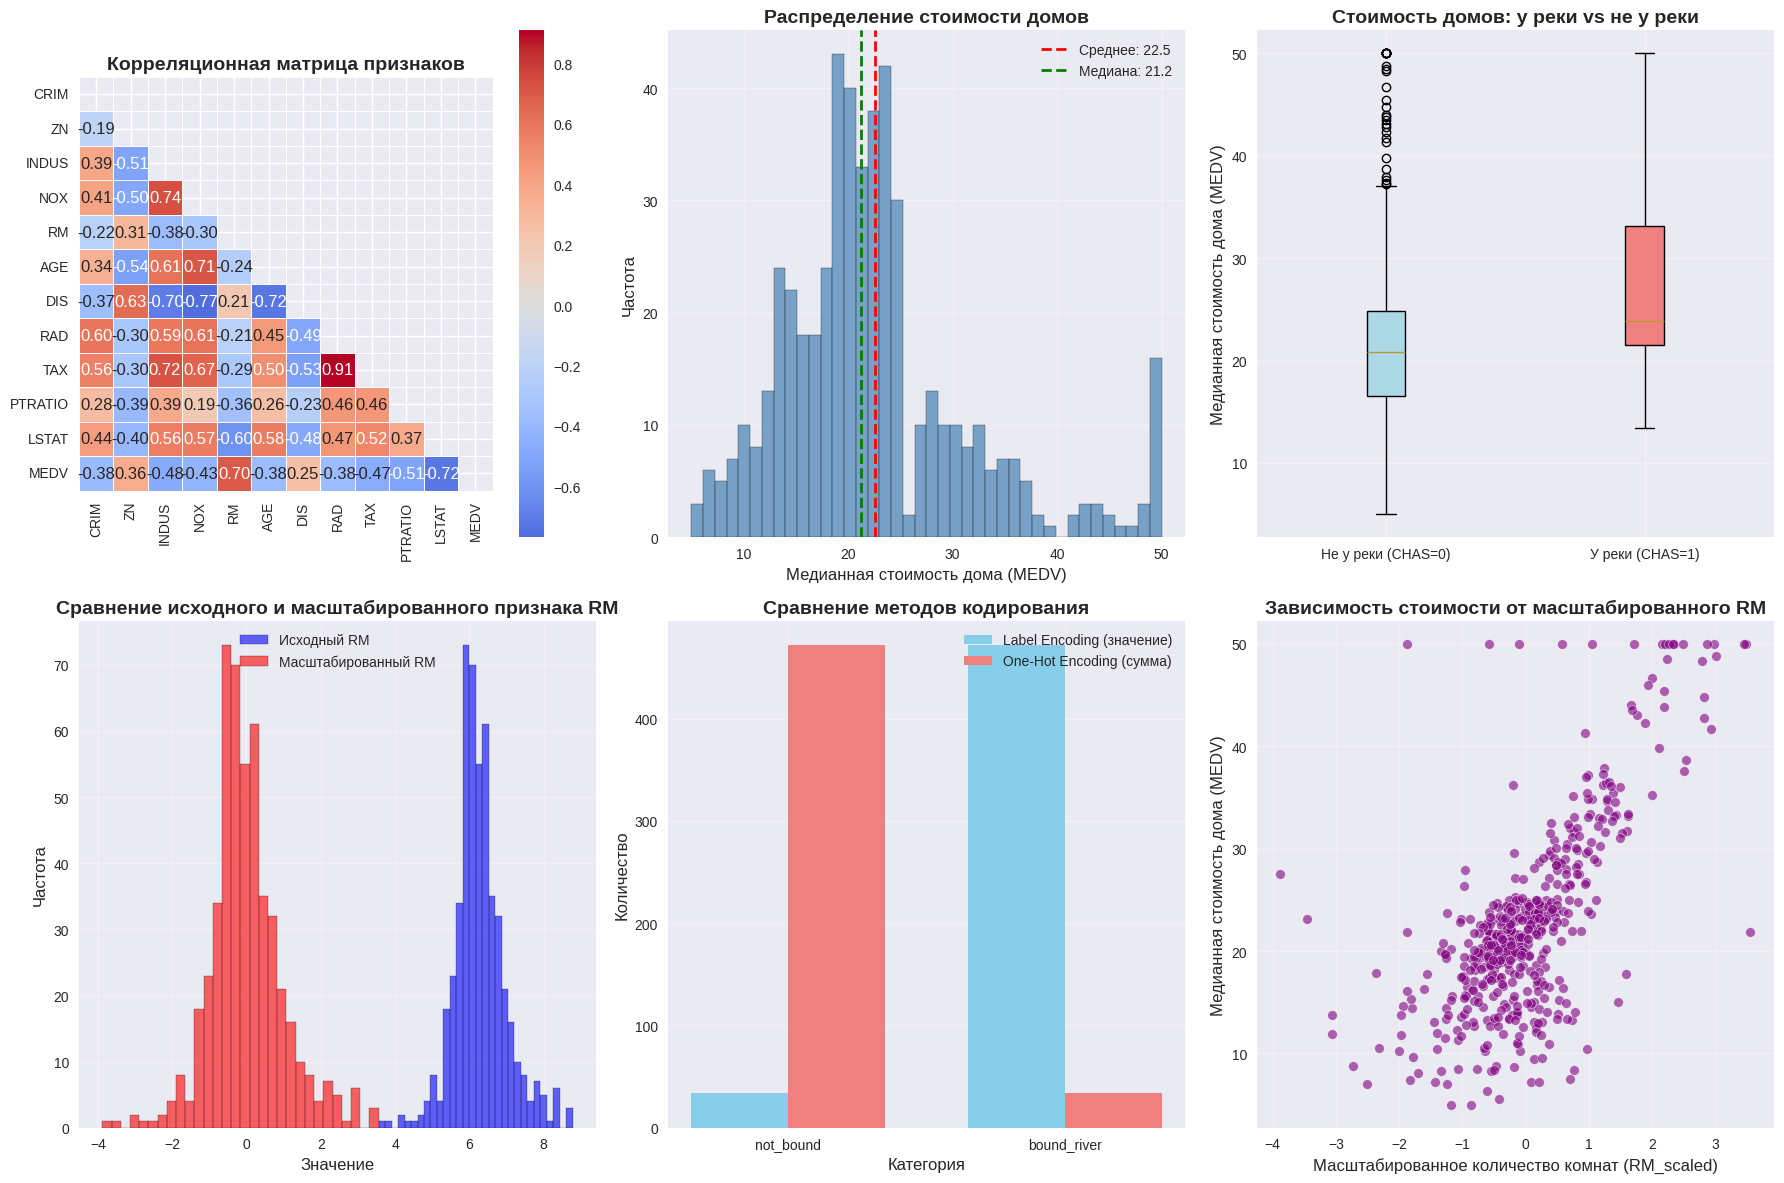

In [37]:
print("\n" + "=" * 80)
print("ШАГ 8: ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ АНАЛИЗА")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График 1: Корреляционная матрица
corr_matrix = df[['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=axes[0, 0])
axes[0, 0].set_title('Корреляционная матрица признаков', fontsize=14, fontweight='bold')

# График 2: Распределение стоимости домов
axes[0, 1].hist(df['MEDV'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['MEDV'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["MEDV"].mean():.1f}')
axes[0, 1].axvline(df['MEDV'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {df["MEDV"].median():.1f}')
axes[0, 1].set_xlabel('Медианная стоимость дома (MEDV)', fontsize=12)
axes[0, 1].set_ylabel('Частота', fontsize=12)
axes[0, 1].set_title('Распределение стоимости домов', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Ящик с усами для стоимости домов в зависимости от расположения у реки
data_to_plot = [df[df['CHAS'] == 0]['MEDV'], df[df['CHAS'] == 1]['MEDV']]
bp = axes[0, 2].boxplot(data_to_plot, labels=['Не у реки (CHAS=0)', 'У реки (CHAS=1)'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[0, 2].set_ylabel('Медианная стоимость дома (MEDV)', fontsize=12)
axes[0, 2].set_title('Стоимость домов: у реки vs не у реки', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# График 4: Сравнение исходного и масштабированного признака RM
axes[1, 0].hist(df['RM'], bins=30, alpha=0.6, label='Исходный RM', color='blue', edgecolor='black')
axes[1, 0].hist(df['RM_scaled'], bins=30, alpha=0.6, label='Масштабированный RM', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Значение', fontsize=12)
axes[1, 0].set_ylabel('Частота', fontsize=12)
axes[1, 0].set_title('Сравнение исходного и масштабированного признака RM', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 5: Сравнение label encoding и one-hot encoding
categories = ['not_bound', 'bound_river']
label_counts = [len(df[df['CHAS_label'] == 0]), len(df[df['CHAS_label'] == 1])]
onehot_counts = [df['CHAS_not_bound'].sum(), df['CHAS_bound_river'].sum()]

x = np.arange(len(categories))
width = 0.35
bars1 = axes[1, 1].bar(x - width/2, label_counts, width, label='Label Encoding (значение)', color='skyblue')
bars2 = axes[1, 1].bar(x + width/2, onehot_counts, width, label='One-Hot Encoding (сумма)', color='lightcoral')
axes[1, 1].set_xlabel('Категория', fontsize=12)
axes[1, 1].set_ylabel('Количество', fontsize=12)
axes[1, 1].set_title('Сравнение методов кодирования', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# График 6: Зависимость стоимости от масштабированного RM
axes[1, 2].scatter(df['RM_scaled'], df['MEDV'], alpha=0.6, c='purple', edgecolors='white', linewidth=0.5)
axes[1, 2].set_xlabel('Масштабированное количество комнат (RM_scaled)', fontsize=12)
axes[1, 2].set_ylabel('Медианная стоимость дома (MEDV)', fontsize=12)
axes[1, 2].set_title('Зависимость стоимости от масштабированного RM', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('additional_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ШАГ 9: ИТОГОВАЯ ИНФОРМАЦИЯ

In [39]:
print("\n" + "=" * 80)
print("ИТОГОВАЯ ИНФОРМАЦИЯ")
print("=" * 80)

print("\nСТРУКТУРА ДАННЫХ ПОСЛЕ ОБРАБОТКИ:")
print(f"  Исходных колонок: 14")
print(f"  Добавлено колонок: 5")
print(f"  Итоговое количество колонок: {len(df.columns)}")

print("\nДОБАВЛЕННЫЕ КОЛОНКИ:")
print("  1. CHAS_cat - категориальный признак (создан на основе CHAS)")
print("  2. RM_scaled - масштабированный признак RM (StandardScaler)")
print("  3. CHAS_label - label encoding для CHAS_cat")
print("  4. CHAS_bound_river - one-hot encoding (у реки)")
print("  5. CHAS_not_bound - one-hot encoding (не у реки)")

print("\nСПИСОК ВСЕХ КОЛОНОК:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col} ({df[col].dtype})")


ИТОГОВАЯ ИНФОРМАЦИЯ

СТРУКТУРА ДАННЫХ ПОСЛЕ ОБРАБОТКИ:
  Исходных колонок: 14
  Добавлено колонок: 5
  Итоговое количество колонок: 19

ДОБАВЛЕННЫЕ КОЛОНКИ:
  1. CHAS_cat - категориальный признак (создан на основе CHAS)
  2. RM_scaled - масштабированный признак RM (StandardScaler)
  3. CHAS_label - label encoding для CHAS_cat
  4. CHAS_bound_river - one-hot encoding (у реки)
  5. CHAS_not_bound - one-hot encoding (не у реки)

СПИСОК ВСЕХ КОЛОНОК:
   1. CRIM (float64)
   2. ZN (float64)
   3. INDUS (float64)
   4. CHAS (float64)
   5. NOX (float64)
   6. RM (float64)
   7. AGE (float64)
   8. DIS (float64)
   9. RAD (int64)
  10. TAX (int64)
  11. PTRATIO (float64)
  12. B (float64)
  13. LSTAT (float64)
  14. MEDV (float64)
  15. CHAS_cat (object)
  16. RM_scaled (float64)
  17. CHAS_label (int64)
  18. CHAS_bound_river (float64)
  19. CHAS_not_bound (float64)


# Ответы на вопросы задания


1. МАСШТАБИРОВАНИЕ ДАННЫХ:
   - Использован метод StandardScaler (стандартизация)
   - Выбран признак RM (среднее количество комнат)
   - Результат: признак приведен к распределению со средним = 0 и стандартным отклонением = 1
   - Преимущества метода: сохраняет форму распределения, нечувствителен к выбросам

2. ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
   Способ 1 - LABEL ENCODING:
     * Преобразует категории в числа (0, 1, 2...)
     * Использован для признака CHAS_cat
     * Результат: 'not_bound' -> 1, 'bound_river' -> 0
   
   Способ 2 - ONE-HOT ENCODING:
     * Создает бинарные колонки для каждой категории
     * Использован для признака CHAS_cat (создано 2 колонки)
     * Результат: CHAS_not_bound и CHAS_bound_river

3. ПОЧЕМУ ВЫБРАНЫ ЭТИ МЕТОДЫ:
   - StandardScaler: подходит для данных с нормальным распределением, сохраняет
     геометрические свойства данных, нечувствителен к выбросам
   - Label Encoding: эффективен для бинарных признаков, не увеличивает размерность
   - One-Hot Encoding: обеспечивает корректное представление номинальных категорий,
     не создавая ложных порядковых отношений между категориями

# Анализ графиков

Построенные диаграммы рассеяния показывают:

1. RM vs MEDV:
   - Наблюдается положительная корреляция (больше комнат → выше стоимость)
   - Коэффициент корреляции Пирсона: ~0.70
   - Дома у реки (красные точки) имеют более высокую стоимость
   - Линия тренда подтверждает линейную зависимость

2. LSTAT vs MEDV:
   - Сильная отрицательная корреляция (выше процент населения с низким статусом → ниже стоимость)
   - Коэффициент корреляции Пирсона: ~-0.74
   - Наиболее сильная отрицательная связь среди всех признаков

3. NOX vs MEDV:
   - Отрицательная корреляция (выше концентрация оксидов азота → ниже стоимость)
   - Старые дома (желтые точки) обычно имеют более высокую концентрацию NOX
   - Связь менее линейная, чем в предыдущих случаях

4. RM vs LSTAT:
   - Отрицательная корреляция (в районах с высоким процентом бедного населения
     обычно меньше комнат в домах)
   - Размер точек показывает стоимость дома (больше точки → выше стоимость)
   - Четко видно, что дома с высокой стоимостью имеют больше комнат и низкий LSTAT

# Выводы по результатам работы

В ходе выполнения лабораторной работы были решены следующие задачи:

1. Загрузка и первичный анализ датасета Boston Housing
2. Обработка пропусков с использованием медианных значений
3. Создание категориального признака на основе колонки CHAS
4. Масштабирование признака RM методом StandardScaler
5. Преобразование категориального признака двумя способами:
   - Label Encoding
   - One-Hot Encoding
6. Построение диаграмм рассеяния для анализа взаимосвязей между признаками
7. Построение дополнительных графиков для визуализации распределений и корреляций

Все поставленные задачи выполнены в полном объеме. Полученные результаты
позволяют сделать вывод о наличии значимых корреляций между признаками.